[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChrisW09/Python-for-AI-Driven-Automation/blob/main/02_data_science/07_pandas_fundamentals.ipynb)

# 📓 Notebook 7 — Pandas Fundamentals: Your First Real DataFrame

> **Module:** Data Science Libraries · **Estimated time:** 30–40 min · **Difficulty:** Beginner

You can do real data work in pure Python — that's exactly what you did with lists (Notebook 3) and dicts (Notebook 4). But once your data is more than a handful of rows, that approach starts to hurt: no column labels, hand-written loops for every filter, a `KeyError` waiting behind every typo. What you actually want is a **proper table** you can *program* — and that is **pandas**.

Pandas is *the* library every data scientist touches every day. This notebook gives you a working preview: enough to be productive, with NumPy (NB 8) and visualization (NB 9) coming next — and pandas in constant use from here on.

> 🧭 **The one question we'll answer all the way through.** In keeping with the course identity, every example uses **one running dataset**: a log of LLM API calls — model, token usage, cost, latency, customer segment. And we'll keep asking it **one business question**: *"What is actually driving our API spend?"* Each new pandas tool is introduced as the next move in answering it — build the table, inspect it, slice it, filter to the expensive calls, derive a cost column, group by model, then plot the answer.

> 🧠 **The mental model to keep.** A DataFrame is a **spreadsheet you can program**: rows are records, columns are `Series`, and *every* operation hands you back a new table or column you can keep working on. Hold that picture and the whole API stops feeling like a grab-bag of methods.

## 🎯 Learning objectives

1. Build a `DataFrame` from a dict and from a CSV.
2. Inspect a new dataset with the standard "first five commands".
3. Select columns and rows (`.loc` vs `.iloc`).
4. Filter rows with **boolean masks** — the pandas idiom.
5. Add derived columns from formulas.
6. Use `groupby` to compute aggregates by category.
7. Draw a first plot directly from a DataFrame.

## ✅ Prerequisites

Notebooks 1–4.

## 1. The pandas mental model — a spreadsheet you can program

Before any spend analysis, get the one picture that makes the rest click. Pandas has two core objects, and together they *are* the spreadsheet-you-can-program from the intro:

| Object        | Conceptually          | Compare to                        |
|---------------|-----------------------|-----------------------------------|
| `Series`      | A single column       | a labelled NumPy 1-D array        |
| `DataFrame`   | A whole table         | a labelled 2-D array / SQL table  |

```
   ┌────────────────  DataFrame  ────────────────┐
   │  request_id   model       tokens   cost    │
   │  req_001      gpt-4o-mini  482     0.00029 │
   │  req_002      claude-haiku 612     0.00037 │
   │  ...                                       │
   └────────────────────────────────────────────┘
                ↑                  ↑
               row              column
            (a record)        (a Series)
```

If you understand a list-of-dicts from Notebook 4, you already understand a DataFrame — pandas just gives you a *much* better toolkit for working with it. Keep the **table → Series → value** zoom levels in mind: almost everything below is just "pick a level and act on it." First we need a table to act on.

In [1]:
# The standard import aliases — you'll see "pd" and "np" in every pandas notebook ever
import pandas as pd
import numpy as np

print(f"pandas version: {pd.__version__}")
print(f"numpy  version: {np.__version__}")


pandas version: 3.0.3
numpy  version: 2.4.6


## 2. Creating a DataFrame from a dict

We can't analyse spend until we have the table. The most natural way to build a small DataFrame is from a dict where **keys are column names** and **values are lists** (one per row) — notice it's just the list-of-dicts idea from Notebook 4, turned on its side. Here's yesterday's API-call batch, the dataset we'll carry through the whole notebook:

In [2]:
# A small log of LLM API calls from yesterday's batch
data = {
    "request_id":     ["req_001", "req_002", "req_003", "req_004", "req_005", "req_006", "req_007", "req_008"],
    "model":          ["gpt-4o-mini", "gpt-4o-mini", "claude-haiku", "gpt-4o-mini",
                       "claude-haiku", "gpt-4o-mini", "claude-haiku", "gpt-4o-mini"],
    "tokens_in":      [482, 612, 510, 1180, 720,  430,  890, 240],
    "tokens_out":     [121, 158, 144,  205, 192,  118,  201,  87],
    "latency_ms":     [1820, 2150, 1640, 3180, 2410, 1740, 2530, 1380],
    "customer_seg":   ["SMB", "Enterprise", "SMB", "Enterprise",
                       "Mid-market", "SMB", "Enterprise", "SMB"],
}

df = pd.DataFrame(data)
df


,request_id,model,tokens_in,tokens_out,latency_ms,customer_seg
0,req_001,gpt-4o-mini,482,121,1820,SMB
1,req_002,gpt-4o-mini,612,158,2150,Enterprise
2,req_003,claude-haiku,510,144,1640,SMB
3,req_004,gpt-4o-mini,1180,205,3180,Enterprise
4,req_005,claude-haiku,720,192,2410,Mid-market
5,req_006,gpt-4o-mini,430,118,1740,SMB
6,req_007,claude-haiku,890,201,2530,Enterprise
7,req_008,gpt-4o-mini,240,87,1380,SMB


**A pandas tip.** Inside Jupyter, just typing the variable name (`df`) at the bottom of a cell renders a beautifully formatted HTML table. Try `print(df)` *and* just `df` — the latter is what you'll prefer.

## 3. Inspecting a DataFrame — look before you analyse

We have a table, but we don't yet *know* it — how many rows? any missing costs? are the numbers stored as numbers or accidentally as text? Jumping straight to "average cost" on a column secretly typed as text is how rookies get nonsense answers. So whenever you meet a new dataset, run these commands first. They tell you the *shape*, the *types*, and the *typical values* before you do anything else. Skipping this step is one of the most common rookie mistakes.

In [3]:
print("Shape (rows, cols):", df.shape)
print("\nColumn names :", df.columns.tolist())
print("\nData types:")
print(df.dtypes)


Shape (rows, cols): (8, 6)

Column names : ['request_id', 'model', 'tokens_in', 'tokens_out', 'latency_ms', 'customer_seg']

Data types:
request_id        str
model             str
tokens_in       int64
tokens_out      int64
latency_ms      int64
customer_seg      str
dtype: object


In [4]:
# The first / last few rows
print("--- head(3) ---")
print(df.head(3))

print("\n--- tail(2) ---")
print(df.tail(2))


--- head(3) ---
  request_id         model  tokens_in  tokens_out  latency_ms customer_seg
0    req_001   gpt-4o-mini        482         121        1820          SMB
1    req_002   gpt-4o-mini        612         158        2150   Enterprise
2    req_003  claude-haiku        510         144        1640          SMB

--- tail(2) ---
  request_id         model  tokens_in  tokens_out  latency_ms customer_seg
6    req_007  claude-haiku        890         201        2530   Enterprise
7    req_008   gpt-4o-mini        240          87        1380          SMB


In [5]:
# Quick statistical summary for numeric columns
df.describe()


,tokens_in,tokens_out,latency_ms
count,8.000000,8.000000,8.000000
mean,633.000000,153.250000,2106.250000
std,294.437963,43.489736,584.023911
min,240.000000,87.000000,1380.000000
25%,469.000000,120.250000,1715.000000
50%,561.000000,151.000000,1985.000000
75%,762.500000,194.250000,2440.000000
max,1180.000000,205.000000,3180.000000


In [6]:
# Schema and non-null counts — your missing-data canary
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   request_id    8 non-null      str  
 1   model         8 non-null      str  
 2   tokens_in     8 non-null      int64
 3   tokens_out    8 non-null      int64
 4   latency_ms    8 non-null      int64
 5   customer_seg  8 non-null      str  
dtypes: int64(3), str(3)
memory usage: 715.0 bytes


---

### ✋ Quick exercise (~2 min) — Size up the log before analysing

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

You've just been handed the `df` of API calls. Before doing any analysis, inspect it: print how many **rows and columns** it has, then show the numeric summary. From that summary, read off the **mean `latency_ms`**.

In [7]:
# ✍️ Your turn 👇
# 1) print the shape (rows, cols)
# 2) show the numeric summary table


<details>
<summary>✅ <b>Solution</b></summary>

```python
print("Shape (rows, cols):", df.shape)
df.describe()   # read the mean off the 'latency_ms' column
```

`.shape` gives `(8, 6)`, and the `mean` row of `df.describe()` shows `latency_ms` ≈ **2106 ms**. Always *look before you analyse*.
</details>

## 4. Selecting columns — zoom in on one piece

We know the shape of the table; now we start *acting* on it. The first zoom level from our mental model is the **column** (a `Series`) — to ask anything about cost or latency, you first have to grab that column. These three patterns appear in every pandas notebook:

```python
df["tokens_in"]                       # one column → Series
df[["request_id", "tokens_in"]]       # several columns → DataFrame
df.tokens_in                          # attribute-style (only when the name is a valid identifier)
```

In [8]:
# One column → Series
tokens = df["tokens_in"]
print(tokens)
print(f"\ntype: {type(tokens).__name__}")


0     482
1     612
2     510
3    1180
4     720
5     430
6     890
7     240
Name: tokens_in, dtype: int64

type: Series


In [9]:
# Several columns → DataFrame
subset = df[["request_id", "model", "tokens_in", "tokens_out"]]
subset


,request_id,model,tokens_in,tokens_out
0,req_001,gpt-4o-mini,482,121
1,req_002,gpt-4o-mini,612,158
2,req_003,claude-haiku,510,144
3,req_004,gpt-4o-mini,1180,205
4,req_005,claude-haiku,720,192
5,req_006,gpt-4o-mini,430,118
6,req_007,claude-haiku,890,201
7,req_008,gpt-4o-mini,240,87


## 5. Selecting rows — `loc` vs `iloc`

Columns answer *"how much did latency cost across all calls?"* But sometimes you want a specific **record** — *"show me request 4."* That means selecting rows, and here pandas gives you **two** ways. The difference matters once your DataFrame has a non-default index.

| Indexer | What it uses          | Endpoint inclusive?   |
|---------|------------------------|-----------------------|
| `.loc`  | **labels** (the index) | yes (`df.loc[0:2]` returns 3 rows) |
| `.iloc` | **integer positions**  | no (`df.iloc[0:2]` returns 2 rows) |

In [10]:
# .loc — label-based
print("df.loc[0]:")
print(df.loc[0])           # first row → Series

print("\ndf.loc[0:2, ['request_id', 'tokens_in']]:")
print(df.loc[0:2, ["request_id", "tokens_in"]])


df.loc[0]:
request_id          req_001
model           gpt-4o-mini
tokens_in               482
tokens_out              121
latency_ms             1820
customer_seg            SMB
Name: 0, dtype: object

df.loc[0:2, ['request_id', 'tokens_in']]:
  request_id  tokens_in
0    req_001        482
1    req_002        612
2    req_003        510


In [11]:
# .iloc — position-based
print("df.iloc[0]:")
print(df.iloc[0])

print("\ndf.iloc[0:2, 0:3]:")
print(df.iloc[0:2, 0:3])    # first 2 rows, first 3 cols


df.iloc[0]:
request_id          req_001
model           gpt-4o-mini
tokens_in               482
tokens_out              121
latency_ms             1820
customer_seg            SMB
Name: 0, dtype: object

df.iloc[0:2, 0:3]:
  request_id        model  tokens_in
0    req_001  gpt-4o-mini        482
1    req_002  gpt-4o-mini        612


> 🎯 **Rule of thumb.** Prefer `.loc` — it reads almost like English. Use `.iloc` only when you really do mean "the *n*-th row" regardless of labels.

### 🔬 What actually happens with `.loc` vs `.iloc`?

The table above says `.loc` uses **labels** and `.iloc` uses **integer positions** — but on the `df` we built, the index *is* `0, 1, 2, …`, so label and position happen to be the same number. That coincidence is exactly why beginners never feel the difference, then get burned later.

To make the distinction undeniable, here is the mental model. Every DataFrame has **two parallel coordinate systems** for its rows:

```text
         the row INDEX (labels)        the row POSITION (0-based)
                  │                              │
   index='c' ──▶  c   ┐                  0  ◀── .iloc[0]
   index='a' ──▶  a   │  .loc['a']       1  ◀── .iloc[1]
   index='b' ──▶  b   ┘                  2  ◀── .iloc[2]
```

- **`.loc[label]`** asks: *"which row carries this label?"* — it looks the label up in the index.
- **`.iloc[pos]`** asks: *"which row sits in this slot?"* — it counts from the top, `0, 1, 2, …`, ignoring the labels entirely.

When the index is the default `0, 1, 2, …` these two questions have the same answer. The moment the index is **anything else** — strings, or integers that got shuffled or filtered — they diverge. Let's force them apart.

#### Proof #1 — a string index makes them visibly different

Below we build a tiny DataFrame whose index is `['c', 'a', 'b']` (not `0, 1, 2`). Now `.loc['a']` and `.iloc[0]` *cannot* be the same row:

- `.loc['a']` → the row **labelled** `'a'` (which sits in the *middle*, position 1)
- `.iloc[0]` → the row in **position 0** (which is labelled `'c'`)

In [12]:
import pandas as pd  # safe to re-import; pandas is already imported as pd above

# A 3-row table whose index is NOT 0,1,2 — the labels are letters in a scrambled order
people = pd.DataFrame(
    {"name": ["Cara", "Ana", "Ben"], "age": [41, 29, 35]},
    index=["c", "a", "b"],
)
print("people:")
print(people)

print("\n.loc['a']  → the row LABELLED 'a' (position 1):")
print(people.loc["a"])

print("\n.iloc[0]   → the row in POSITION 0 (label 'c'):")
print(people.iloc[0])

# The punchline: same DataFrame, different rows, because the question is different.
print("\nSame row? ", people.loc["a"]["name"], "vs", people.iloc[0]["name"])

people:
   name  age
c  Cara   41
a   Ana   29
b   Ben   35

.loc['a']  → the row LABELLED 'a' (position 1):
name    Ana
age      29
Name: a, dtype: object

.iloc[0]   → the row in POSITION 0 (label 'c'):
name    Cara
age       41
Name: c, dtype: object

Same row?  Ana vs Cara


#### Proof #2 — the trap that bites everyone: integer labels after a filter

The string-index case is easy to spot. The *dangerous* case is when the index is still made of **integers**, but they're no longer `0, 1, 2, …` — which happens automatically the instant you filter, sort, or drop rows. Now `.loc[2]` and `.iloc[2]` are both "two", but they mean completely different rows.

```text
After filtering, the integer index has GAPS — labels ≠ positions:

   index   position   player
     10        0        Ann
     20        1        Bob     ◀── .loc[20] uses the LABEL 20, not the slot
     40        2        Cy      ◀── .iloc[2] lands HERE (3rd slot, position 2)
     70        3        Dee

   .loc[2]  ──▶  KeyError: no row is LABELLED 2
```

The cell below builds a DataFrame with integer labels `[10, 20, 40, 70]`, then shows `.loc[20]` (label → Bob) and `.iloc[2]` (position → Cy) returning different rows — and shows that `.loc[2]` *raises a KeyError* because no row is labelled `2`.

In [13]:
# Integer labels that are NOT 0,1,2 — exactly what you get after filtering/dropping rows
scores = pd.DataFrame(
    {"player": ["Ann", "Bob", "Cy", "Dee"], "score": [50, 60, 70, 80]},
    index=[10, 20, 40, 70],
)
print("scores:")
print(scores)

print("\n.loc[20] → LABEL 20  (2nd row, Bob):")
print(scores.loc[20])

print("\n.iloc[2] → POSITION 2 (3rd row, Cy):")
print(scores.iloc[2])

# .loc[2] would raise KeyError: there is no row labelled 2.
# We catch it instead of letting it crash, to prove the point safely.
try:
    scores.loc[2]
except KeyError as e:
    print("\nscores.loc[2] raised KeyError -> no row is LABELLED 2:", e)

scores:
   player  score
10    Ann     50
20    Bob     60
40     Cy     70
70    Dee     80

.loc[20] → LABEL 20  (2nd row, Bob):
player    Bob
score      60
Name: 20, dtype: object

.iloc[2] → POSITION 2 (3rd row, Cy):
player    Cy
score     70
Name: 40, dtype: object

scores.loc[2] raised KeyError -> no row is LABELLED 2: 2


#### The slicing gotcha — `.loc` is end-INCLUSIVE, `.iloc` is end-EXCLUSIVE

There is one more difference that surprises people, and it's the opposite of normal Python. A plain Python slice `[0:2]` gives you 2 items (stops *before* 2). `.iloc` follows that rule — but `.loc` does **not**: because it slices by *label*, it includes the endpoint label.

| Expression | Counts by | Endpoint | Rows returned for `[0:2]` |
|---|---|---|---|
| `list[0:2]` / `.iloc[0:2]` | position | **excluded** | 2 rows (0, 1) |
| `.loc[0:2]` | label | **included** | 3 rows (0, 1, 2) |

Why the difference? With positions, "stop before 2" is natural. With labels, pandas can't know what label comes "just before" your endpoint (labels can be strings, dates, gaps…), so it includes the endpoint you named. The cell proves both counts on the *same* default-index frame.

In [14]:
demo = pd.DataFrame({"x": [10, 20, 30, 40, 50]})  # default index 0..4
print("demo:")
print(demo)

print("\n.iloc[0:2] → 2 rows (end EXCLUDED, like normal Python):")
print(demo.iloc[0:2])

print("\n.loc[0:2]  → 3 rows (end INCLUDED, because it's a LABEL slice):")
print(demo.loc[0:2])

print("\nRow counts -> iloc[0:2]:", len(demo.iloc[0:2]), " | loc[0:2]:", len(demo.loc[0:2]))

demo:
    x
0  10
1  20
2  30
3  40
4  50

.iloc[0:2] → 2 rows (end EXCLUDED, like normal Python):
    x
0  10
1  20

.loc[0:2]  → 3 rows (end INCLUDED, because it's a LABEL slice):
    x
0  10
1  20
2  30

Row counts -> iloc[0:2]: 2  | loc[0:2]: 3


> 🧠 **Mental model to keep.** Read `.loc` as **"by name"** and `.iloc` as **"by slot number"**.
> Translate in your head every time:
> - `df.loc["a"]` → "the row *named* `a`"
> - `df.iloc[0]` → "the row in *slot* 0, whatever it's named"
>
> 🎯 **Intuition.** As long as the index is the default `0, 1, 2, …`, both give the same answer and you can be sloppy. The bug appears *later*, after a `df[df.age > 30]`, a `.sort_values()`, or a `.drop()` re-labels or gaps the index — then `.iloc[2]` and `.loc[2]` part ways. Pick the one that matches your *intent*: position → `.iloc`, name → `.loc`.

---

### ✋ Quick exercise (~2 min) — `.loc` vs `.iloc` in practice

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

A teammate wants a quick look at the first three calls. Use **`.loc`** to select rows with labels `0` to `2` showing only the `model` and `latency_ms` columns. Then use **`.iloc`** to grab the **very last row** of the table.

In [15]:
# ✍️ Your turn 👇
# .loc for rows 0..2, columns model & latency_ms
# .iloc for the last row


<details>
<summary>✅ <b>Solution</b></summary>

```python
print(df.loc[0:2, ["model", "latency_ms"]])   # .loc is end-INCLUSIVE -> rows 0,1,2
print(df.iloc[-1])                              # last row by position
```

Remember `.loc` is label-based and **includes** the end label, while `.iloc` is position-based, so `-1` cleanly means "the last slot".
</details>

## 6. Filtering — the boolean-mask idiom

Picking one row by name is fine, but our spend question needs *all the rows that match a rule* — "every large-prompt call," "the slow expensive ones." Hand-writing a loop for that is exactly the pain we left pure Python to escape. The pandas answer is **the** pattern of the whole library: build a Series of `True`/`False` values that says which rows you want, then index the DataFrame with it.

```python
df[ df["tokens_in"] > 500 ]
   └────────────────────┘
   boolean Series the same length as df
```

In [16]:
# Step 1: build the mask
mask = df["tokens_in"] > 500
print("Mask:")
print(mask)

# Step 2: apply it
print("\nLarge-prompt requests:")
print(df[mask])


Mask:
0    False
1     True
2     True
3     True
4     True
5    False
6     True
7    False
Name: tokens_in, dtype: bool

Large-prompt requests:
  request_id         model  tokens_in  tokens_out  latency_ms customer_seg
1    req_002   gpt-4o-mini        612         158        2150   Enterprise
2    req_003  claude-haiku        510         144        1640          SMB
3    req_004   gpt-4o-mini       1180         205        3180   Enterprise
4    req_005  claude-haiku        720         192        2410   Mid-market
6    req_007  claude-haiku        890         201        2530   Enterprise


In [17]:
# Combining conditions — note the parentheses around each part, and & (not `and`)
big_and_slow = df[(df["tokens_in"] > 500) & (df["latency_ms"] > 2000)]
print("Big AND slow requests:")
print(big_and_slow)

# OR uses |
enterprise_or_huge = df[(df["customer_seg"] == "Enterprise") | (df["tokens_in"] > 1000)]
print("\nEnterprise OR very long:")
print(enterprise_or_huge)


Big AND slow requests:
  request_id         model  tokens_in  tokens_out  latency_ms customer_seg
1    req_002   gpt-4o-mini        612         158        2150   Enterprise
3    req_004   gpt-4o-mini       1180         205        3180   Enterprise
4    req_005  claude-haiku        720         192        2410   Mid-market
6    req_007  claude-haiku        890         201        2530   Enterprise

Enterprise OR very long:
  request_id         model  tokens_in  tokens_out  latency_ms customer_seg
1    req_002   gpt-4o-mini        612         158        2150   Enterprise
3    req_004   gpt-4o-mini       1180         205        3180   Enterprise
6    req_007  claude-haiku        890         201        2530   Enterprise


> ⚠️ Two common stumbles:
> - Use **`&` and `|`**, *not* `and` / `or`, for element-wise boolean operations.
> - **Wrap each condition in parentheses** — `&` and `|` have higher precedence than `>` and `==`.

### 🔬 What actually happens in `df[df.age > 30]`?

That one-liner feels magic, but it's two ordinary, separable steps glued together. Pulling them apart is what makes filtering stop being scary.

**Step 1 — the comparison builds a boolean Series.** `df["age"] > 30` does *not* return some rows. It compares **every** value to 30 and produces a brand-new Series of `True`/`False`, the **same length** as the DataFrame, with the **same index**:

```text
   age            df["age"] > 30
  ─────           ──────────────
   41    ──▶          True
   29    ──▶          False
   35    ──▶          True
```

**Step 2 — indexing with that mask keeps the `True` rows.** When you put a boolean Series inside `df[ ... ]`, pandas walks down it and keeps **only the rows where the value is `True`**, dropping every `False`:

```text
df[ mask ]
   row 0  True   ──▶  KEEP
   row 1  False  ──▶  drop
   row 2  True   ──▶  KEEP
```

So `df[df.age > 30]` literally means *"build a True/False checklist from the ages, then keep the checked rows."* The mask is a real, inspectable object — you can store it in a variable and print it, which is the best way to debug a filter that returns the wrong rows.

In [18]:
# Build a tiny frame so the whole filter fits on screen
crew = pd.DataFrame({
    "name": ["Ana", "Ben", "Cara", "Dan"],
    "age":  [29, 41, 35, 24],
    "role": ["pilot", "pilot", "nav", "nav"],
})

# Step 1: the comparison is just a boolean Series — print it and SEE it
mask = crew["age"] > 30
print("The mask (a boolean Series, same length & index as crew):")
print(mask)
print("dtype:", mask.dtype)   # bool

# Step 2: indexing with the mask keeps the True rows
print("\ncrew[mask] keeps only rows where the mask is True:")
print(crew[mask])

The mask (a boolean Series, same length & index as crew):
0    False
1     True
2     True
3    False
Name: age, dtype: bool
dtype: bool

crew[mask] keeps only rows where the mask is True:
   name  age   role
1   Ben   41  pilot
2  Cara   35    nav


#### Combining masks — `&`, `|`, and the parentheses that are NOT optional

To filter on two conditions you combine two boolean Series **element-wise**:

- `&` → AND (True only where *both* are True)
- `|` → OR  (True where *either* is True)
- `~` → NOT (flips True/False)

```text
   age>30    role=="pilot"     (age>30) & (role=="pilot")
   ──────    ─────────────     ──────────────────────────
   False        True       ▶          False
   True         True       ▶          True
   True         False      ▶          False
   False        False      ▶          False
```

Two rules that trip up everyone:

1. **Use `&` / `|`, never `and` / `or`.** Python's `and`/`or` work on a *single* True/False, but a mask is a whole Series of them — pandas can't reduce "a column of Trues" to one yes/no, so `and` raises `ValueError: The truth value of a Series is ambiguous`.
2. **Parenthesise each condition.** `&` and `|` bind *tighter* than `>` and `==`. So `df.age > 30 & df.role == "pilot"` is parsed as `df.age > (30 & df.role) == "pilot"` — nonsense. Wrap each comparison: `(df.age > 30) & (df.role == "pilot")`.

In [19]:
# AND — both conditions must hold (note the parentheses around EACH comparison)
pilots_over_30 = crew[(crew["age"] > 30) & (crew["role"] == "pilot")]
print("Pilots over 30:")
print(pilots_over_30)

# OR — either condition
navs_or_young = crew[(crew["role"] == "nav") | (crew["age"] < 28)]
print("\nNavigators OR under 28:")
print(navs_or_young)

# NOT — flip a mask with ~
not_pilots = crew[~(crew["role"] == "pilot")]
print("\nEveryone who is NOT a pilot:")
print(not_pilots)

Pilots over 30:
  name  age   role
1  Ben   41  pilot

Navigators OR under 28:
   name  age role
2  Cara   35  nav
3   Dan   24  nav

Everyone who is NOT a pilot:
   name  age role
2  Cara   35  nav
3   Dan   24  nav


In [20]:
# Why the parentheses matter: without them, operator precedence raises an error.
# We trigger it on purpose and catch it, to prove the failure is real.
try:
    crew[crew["age"] > 30 & crew["role"] == "pilot"]   # MISSING parentheses
except Exception as e:
    print("\nWithout parentheses ->", type(e).__name__, ":", e)


Without parentheses -> TypeError : operation 'rand_' not supported for dtype 'str' with object of type <class 'int'>


### ⚠️ Pitfall — chained indexing and the `ChainedAssignmentError`

Filtering hides a subtle trap when you try to *write* through a filter using **chained indexing**: two square-bracket operations back to back.

```text
df[df.age > 30]["bonus"] = 999
└──── #1 ────┘ └─ #2 ─┘
   selection      assignment
```

Here pandas evaluates `df[df.age > 30]` *first*, producing a **temporary** object, and then `["bonus"] = 999` assigns into **that temporary** — not into `df`. Under **Copy-on-Write** (the default since pandas 2.0, and the *only* behaviour in pandas 3.0), that temporary always behaves as an independent copy, so the write **never reaches `df`**. Because this can only ever be a silent no-op, pandas refuses to stay quiet and raises a **`ChainedAssignmentError`** warning.

> 💡 In older code and tutorials (pandas < 2.0) you'll meet the historical name for this same trap: **`SettingWithCopyWarning`**. Back then the outcome was genuinely unpredictable — sometimes the write landed, sometimes it didn't. Copy-on-Write removed the ambiguity: now it *deterministically* never lands, which is why the modern warning is firmer.

**The fix is to do the select-and-assign in a *single* `.loc` call**, so pandas targets the original frame directly:

```python
df.loc[df.age > 30, "bonus"] = 999     # ✅ one operation: rows by mask, column by name
```

This ties back to **mutability**: a DataFrame is a mutable object, and `.loc[...] = ...` mutates it *in place*. Chained indexing breaks because the *first* bracket hands you a separate copy before the assignment runs. Rule of thumb: **to assign into a filtered slice, always use one `.loc[mask, col] = value`.** The cell below shows the correct form working, then reproduces (and safely swallows) the warning.


In [21]:
import warnings

# Start every demo from a clean, independent copy so re-running is deterministic
base = crew.copy()
base["bonus"] = 0     # add a column to write into

# ✅ CORRECT — single .loc call: select rows by mask AND column by name, assign in place
base.loc[base["age"] > 30, "bonus"] = 999
print("After df.loc[mask, 'bonus'] = 999  (the right way):")
print(base)

After df.loc[mask, 'bonus'] = 999  (the right way):
   name  age   role  bonus
0   Ana   29  pilot      0
1   Ben   41  pilot    999
2  Cara   35    nav    999
3   Dan   24    nav      0


In [22]:
# ⚠️ The buggy pattern: chained indexing. Under Copy-on-Write it assigns to a
# throwaway copy and raises ChainedAssignmentError. We capture the warning so the
# cell runs cleanly, and confirm the write never reached the original frame.
buggy = crew.copy()
buggy["bonus"] = 0
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    buggy[buggy["age"] > 30]["bonus"] = 777     # chained indexing — the trap
    warned = [w for w in caught if "ChainedAssignment" in str(w.category)]

print("\nChained-indexing attempt buggy[mask]['bonus'] = 777")
print("  ChainedAssignmentError raised? ", len(warned) > 0)
print("  Did the value 777 actually land in 'buggy'? ", (buggy["bonus"] == 777).any(),
      "  <- always False under Copy-on-Write: the write hit a throwaway copy")
print("\nLesson: use one .loc[mask, col] = value, never df[mask][col] = value.")


Chained-indexing attempt buggy[mask]['bonus'] = 777
  ChainedAssignmentError raised?  True
  Did the value 777 actually land in 'buggy'?  False   <- always False under Copy-on-Write: the write hit a throwaway copy

Lesson: use one .loc[mask, col] = value, never df[mask][col] = value.


## 7. Adding and modifying columns — from raw data to the KPI

Here's the snag: our table has `tokens` and `model`, but **no `cost` column** — and cost is the very thing our running question is about. So we have to *derive* it. Adding columns from a formula is how you turn raw data into business KPIs, and it's where the "spreadsheet you can program" idea earns its keep:

In [23]:
# A simple price table (you'd normally load this from config)
prices_per_1k = {
    "gpt-4o-mini" : {"in": 0.0006, "out": 0.0024},
    "claude-haiku": {"in": 0.0008, "out": 0.0040},
}

# .map(func) runs a function on every value of the column.
# Here the function looks each model name up in the price table above.
df["price_in_per_1k"]  = df["model"].map(lambda m: prices_per_1k[m]["in"])
df["price_out_per_1k"] = df["model"].map(lambda m: prices_per_1k[m]["out"])

In [24]:
# Compute the cost of every request — vectorised arithmetic, no loop needed
df["cost_usd"] = (df["tokens_in"]  / 1000 * df["price_in_per_1k"] +
                  df["tokens_out"] / 1000 * df["price_out_per_1k"])

# A boolean column — was this a slow call?
df["was_slow"] = df["latency_ms"] > 2000

In [25]:
# pd.cut slices a numeric column into labelled bands.
# Note: `bins` needs one more edge than there are `labels`; np.inf = "no upper limit".
df["latency_band"] = pd.cut(
    df["latency_ms"],
    bins=[0, 1500, 2500, np.inf],
    labels=["fast", "medium", "slow"],
)

df

,request_id,model,tokens_in,tokens_out,latency_ms,customer_seg,price_in_per_1k,price_out_per_1k,cost_usd,was_slow,latency_band
0,req_001,gpt-4o-mini,482,121,1820,SMB,0.0006,0.0024,0.000580,False,medium
1,req_002,gpt-4o-mini,612,158,2150,Enterprise,0.0006,0.0024,0.000746,True,medium
2,req_003,claude-haiku,510,144,1640,SMB,0.0008,0.0040,0.000984,False,medium
3,req_004,gpt-4o-mini,1180,205,3180,Enterprise,0.0006,0.0024,0.001200,True,slow
4,req_005,claude-haiku,720,192,2410,Mid-market,0.0008,0.0040,0.001344,True,medium
5,req_006,gpt-4o-mini,430,118,1740,SMB,0.0006,0.0024,0.000541,False,medium
6,req_007,claude-haiku,890,201,2530,Enterprise,0.0008,0.0040,0.001516,True,slow
7,req_008,gpt-4o-mini,240,87,1380,SMB,0.0006,0.0024,0.000353,False,fast


> 🎯 **Vectorised vs loops.** Notice we did *not* write a `for` loop to compute `cost_usd`. Pandas computes the formula for every row at once. This is faster *and* shorter than a loop — it's why you reach for pandas in the first place.

---

### ✋ Quick exercise (~2 min) — Engineer a new column

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

Add a **vectorised** column `tokens_total` = `tokens_in` + `tokens_out` (no `for` loop!). Then add a **boolean** column `is_big` that flags requests whose total tokens exceed 1000.

In [26]:
# ✍️ Your turn 👇
df["tokens_total"] = ...
df["is_big"] = ...
df[["request_id", "tokens_total", "is_big"]]


,request_id,tokens_total,is_big
0,req_001,Ellipsis,Ellipsis
1,req_002,Ellipsis,Ellipsis
2,req_003,Ellipsis,Ellipsis
3,req_004,Ellipsis,Ellipsis
4,req_005,Ellipsis,Ellipsis
5,req_006,Ellipsis,Ellipsis
6,req_007,Ellipsis,Ellipsis
7,req_008,Ellipsis,Ellipsis


<details>
<summary>✅ <b>Solution</b></summary>

```python
df["tokens_total"] = df["tokens_in"] + df["tokens_out"]
df["is_big"] = df["tokens_total"] > 1000
df[["request_id", "tokens_total", "is_big"]]
```

Both operations run on the whole column at once — the arithmetic and the `>` comparison are vectorised, just like the `cost_usd` formula above.
</details>

## 8. Summary statistics & `value_counts`

Now that a real `cost_usd` column exists, we can start reading the numbers off the table directly — the per-column summaries (`mean`, `median`, `std`) and the category tallies (`value_counts`) that turn a column into a one-line headline.

In [27]:
print("Latency stats (ms):")
print(f"  mean   : {df['latency_ms'].mean():.0f}")
print(f"  median : {df['latency_ms'].median():.0f}")
print(f"  std    : {df['latency_ms'].std():.0f}")
print(f"  min    : {df['latency_ms'].min()}")
print(f"  max    : {df['latency_ms'].max()}")

print("\nRequests per model:")
print(df["model"].value_counts())

print("\nRequests per customer segment:")
print(df["customer_seg"].value_counts())


Latency stats (ms):
  mean   : 2106
  median : 1985
  std    : 584
  min    : 1380
  max    : 3180

Requests per model:
model
gpt-4o-mini     5
claude-haiku    3
Name: count, dtype: int64

Requests per customer segment:
customer_seg
SMB           4
Enterprise    3
Mid-market    1
Name: count, dtype: int64


### 📊 The same counts, as a picture

The two `value_counts` tallies above are much easier to compare as bars — one glance shows how requests split across models and segments.

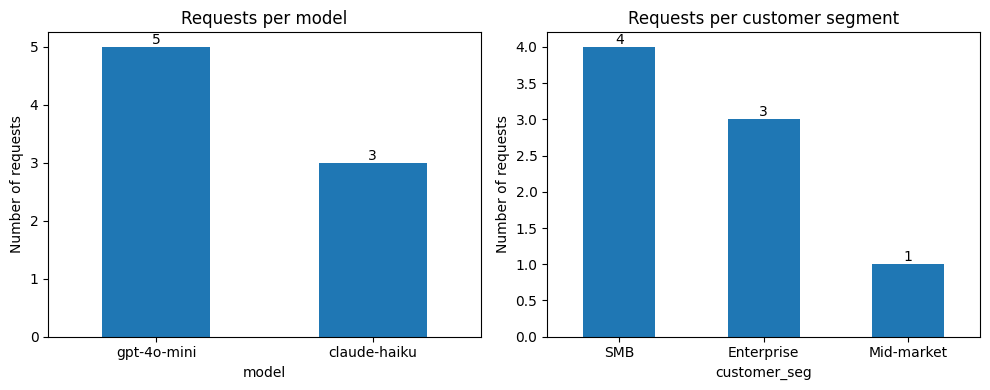

In [28]:
import matplotlib.pyplot as plt

# The two value_counts above, drawn as bars so the categories are easy to compare
model_counts = df["model"].value_counts()
seg_counts   = df["customer_seg"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
model_counts.plot(kind="bar", ax=axes[0], rot=0, title="Requests per model")
seg_counts.plot(kind="bar", ax=axes[1], rot=0, title="Requests per customer segment")
for ax in axes:
    ax.set_ylabel("Number of requests")
    ax.bar_label(ax.containers[0])
plt.tight_layout()
plt.show()

### 🔮 Predict the output

A column has a missing value. What does `.mean()` use as its denominator — the number of rows, or the number of *non-missing* values?

```python
import pandas as pd
import numpy as np

s = pd.Series([10, 20, np.nan, 30])
print(s.sum())
print(s.mean())
```

Predict both numbers **before** running. Is `mean` just `sum / 4`?

In [29]:
import pandas as pd
import numpy as np

s = pd.Series([10, 20, np.nan, 30])
print("sum :", s.sum())
print("mean:", s.mean())

sum : 60.0
mean: 20.0


<details>
<summary>💡 <b>Answer</b></summary>

**`sum` is `60.0`; `mean` is `20.0`, not `15.0`.** By default pandas **skips `NaN`** (`skipna=True`). `sum()` adds the three real values (`60`), and `mean()` divides by the count of *non-missing* values (`60 / 3 = 20`) — **not** by the four rows. So a missing value is treated as *absent*, never as a zero. If you genuinely want `NaN` to propagate, pass `skipna=False`; if you want it counted as `0`, call `.fillna(0)` first.
</details>

> 🚫 **Misconception — "a missing value counts as 0 in `.mean()` / `.sum()`."**
> By default pandas *ignores* `NaN` (`skipna=True`): `.sum()` omits it and `.mean()` divides by the count of **non-missing** values, not the row count. Treating gaps as zeros (call `.fillna(0)` first) can silently change every average — decide which you want on purpose.

## 9. `groupby` — the most useful pandas verb

A single overall mean hides the thing we most want to know: *spend by model.* That's the real shape of our running question — *"cost broken down by category"* — and `groupby` is the verb that answers it. `groupby` answers questions of the form *"what's the *something* of *something_else*, broken down by *category*?"*. For instance: *"average cost per request, by model"*, *"total tokens, by customer segment"*, *"slow-call rate by model"*.

The mental model is **split → apply → combine**:

```
                    apply (mean, sum, count, …)
                       ↓
   ┌─ gpt-4o-mini : ████  →  $0.0014 / call
df ┤
   └─ claude-haiku: ███   →  $0.0021 / call
                                 ↑
                              combine
```

In [30]:
# Average cost per request, per model
print("Mean cost per request, by model:")
print(df.groupby("model")["cost_usd"].mean().round(6))

# Multiple aggregations at once, by model
agg = df.groupby("model").agg(
    n_calls         =("request_id", "count"),
    total_tokens    =("tokens_in",  "sum"),
    mean_latency_ms =("latency_ms", "mean"),
    total_cost      =("cost_usd",   "sum"),
).round(4)
agg


Mean cost per request, by model:
model
claude-haiku    0.001281
gpt-4o-mini     0.000684
Name: cost_usd, dtype: float64


,n_calls,total_tokens,mean_latency_ms,total_cost
model,,,,
claude-haiku,3,2120,2193.3333,0.0038
gpt-4o-mini,5,2944,2054.0000,0.0034


In [31]:
# Grouping by two columns — model and customer segment
cross = df.groupby(["model", "customer_seg"]).agg(
    n          =("request_id", "count"),
    mean_cost  =("cost_usd",   "mean"),
).round(5)
cross


n  mean_cost
model        customer_seg              
claude-haiku Enterprise    1    0.00152
             Mid-market    1    0.00134
             SMB           1    0.00098
gpt-4o-mini  Enterprise    2    0.00097
             SMB           3    0.00049

---

### ✋ Quick exercise (~2 min) — Cost per customer segment

> 🧑‍🏫 *Live checkpoint — pause and try this before peeking at the solution.*

Marketing asks: *what does an average request cost for each customer segment?* Use `groupby` on `customer_seg` to get the **mean `cost_usd`**. Bonus: how many calls came from each segment?

In [32]:
# ✍️ Your turn 👇
# mean cost_usd per customer_seg
# bonus: count of calls per segment


<details>
<summary>✅ <b>Solution</b></summary>

```python
print(df.groupby("customer_seg")["cost_usd"].mean().round(6))
print(df["customer_seg"].value_counts())   # bonus: calls per segment
```

`groupby("customer_seg")["cost_usd"].mean()` splits by segment and averages each group; `value_counts()` tallies how many rows fall in each segment.
</details>

## 10. Reading and writing CSV files

So far we *typed* our data into a dict — fine for a demo, hopeless for the real 50,000-row log sitting in a file. Real projects start by **loading** a CSV and end by **saving** the enriched result. Pandas reads dozens of formats (CSV, Excel, JSON, Parquet, SQL, …) with a one-line call, and the loaded table behaves exactly like the one we built by hand:

In [33]:
# Reading from a string is great for self-contained demos.
# In a real notebook this would be:  api_log = pd.read_csv("api_log.csv")

from io import StringIO

csv_text = '''request_id,model,tokens_in,tokens_out,latency_ms,customer_seg
req_009,gpt-4o-mini,520,140,1900,SMB
req_010,claude-haiku,810,210,2380,Enterprise
req_011,gpt-4o-mini,295,82,1420,SMB
req_012,gpt-4o-mini,1050,260,3050,Enterprise
req_013,claude-haiku,640,170,2210,Mid-market
req_014,gpt-4o-mini,470,128,1810,SMB
req_015,claude-haiku,920,235,2670,Enterprise
'''

api_log = pd.read_csv(StringIO(csv_text))
print(api_log)
print(f"\nShape: {api_log.shape}")


  request_id         model  tokens_in  tokens_out  latency_ms customer_seg
0    req_009   gpt-4o-mini        520         140        1900          SMB
1    req_010  claude-haiku        810         210        2380   Enterprise
2    req_011   gpt-4o-mini        295          82        1420          SMB
3    req_012   gpt-4o-mini       1050         260        3050   Enterprise
4    req_013  claude-haiku        640         170        2210   Mid-market
5    req_014   gpt-4o-mini        470         128        1810          SMB
6    req_015  claude-haiku        920         235        2670   Enterprise

Shape: (7, 6)


In [34]:
# Group-by on the loaded data: tokens per segment
tokens_by_seg = api_log.groupby("customer_seg")[["tokens_in", "tokens_out"]].sum()
print(tokens_by_seg)

# To save: api_log.to_csv("api_log.csv", index=False)


              tokens_in  tokens_out
customer_seg                       
Enterprise         2780         705
Mid-market          640         170
SMB                1285         350


## 11. A first plot — `df.plot()` answers the question on screen

We've computed cost-by-model as numbers; the last step of any analysis is making the answer *land* — a chart says "this model is the spend driver" faster than a table ever will. Pandas has a built-in `.plot()` method that wraps matplotlib, perfect for quick exploration. We'll do plotting properly in Notebook 9; for now, the payoff of our running question, drawn in one line:

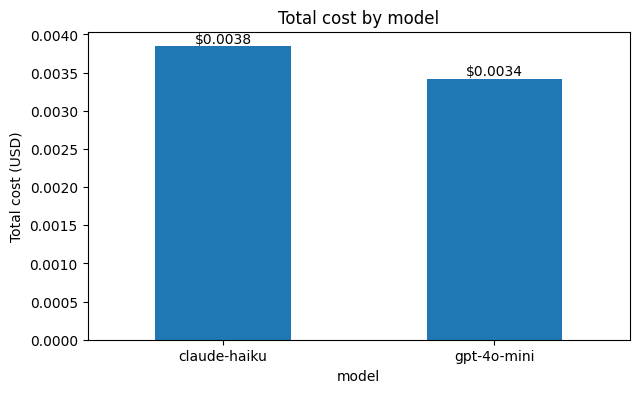

In [35]:
import matplotlib.pyplot as plt

# Total cost per model — a quick bar chart
cost_by_model = df.groupby("model")["cost_usd"].sum().sort_values(ascending=False)

ax = cost_by_model.plot(kind="bar", title="Total cost by model", figsize=(7, 4), rot=0)
ax.set_ylabel("Total cost (USD)")
ax.bar_label(ax.containers[0], fmt="$%.4f")   # value labels in one line — no loop needed
plt.show()


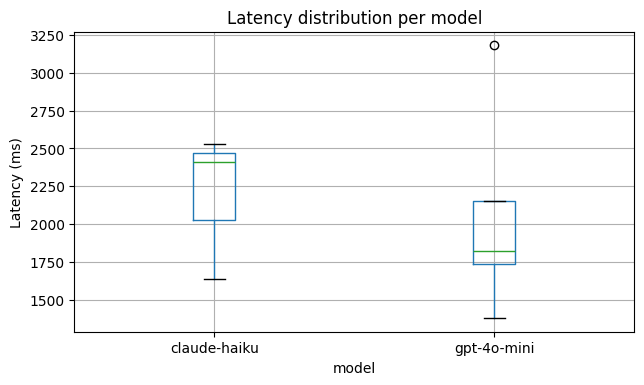

In [36]:
# Latency distribution per model — boxplot, grouped with `by=`
ax = df.boxplot(column="latency_ms", by="model", figsize=(7, 4))
ax.set_title("Latency distribution per model")
ax.set_ylabel("Latency (ms)")
plt.suptitle("")     # suppress the extra figure title pandas adds
plt.show()


## 12. The pandas patterns you'll see everywhere

Burn these into memory — they form the daily-use vocabulary of every data scientist:

```python
# Loading
df = pd.read_csv("data.csv")

# Exploring
df.head()                       # see the first rows
df.shape                        # rows, cols
df.describe()                   # summary stats
df.info()                       # types and missing counts

# Selecting
df["col"]                       # one column → Series
df[["col1", "col2"]]            # several columns → DataFrame
df.loc[label, "col"]            # row by label, column by name
df.iloc[0, 0]                   # row by position, column by position

# Filtering
df[df["col"] > 100]
df[(df["col1"] > 100) & (df["col2"] == "x")]

# Adding columns
df["new"] = df["a"] * df["b"]
df["band"] = pd.cut(df["score"], bins=..., labels=...)

# Aggregating
df.groupby("category")["value"].mean()
df.groupby("category").agg(total=("value", "sum"))

# Quick visual
df["amount"].plot(kind="hist", bins=30)
```

Once these feel automatic, the rest of pandas is "more of the same".

> 🧠 **The thread, end to end.** Look back at what we just did to one little API log: we **built** the table (§2), **inspected** it before trusting it (§3), zoomed into **columns** and **rows** (§4–5), **filtered** to the rows that mattered (§6), **derived** the missing `cost_usd` KPI (§7), **summarised** and **grouped** it to spend-by-model (§8–9), loaded/saved it as a **CSV** (§10), and **plotted** the answer (§11). That build → inspect → slice → derive → aggregate → visualise → save loop *is* day-to-day data science — every later notebook is this same arc on richer data.

## 🧪 Practice exercises

For the next exercises we'll use a slightly larger synthetic dataset: 50 API calls across models, segments, and quarters.

In [37]:
rng = np.random.default_rng(42)
n = 50

api_data = pd.DataFrame({
    "request_id": [f"req_{i:03d}" for i in range(1, n + 1)],
    "model":      rng.choice(["gpt-4o-mini", "claude-haiku", "gpt-4o"], n),
    "segment":    rng.choice(["SMB", "Mid-market", "Enterprise"], n),
    "quarter":    rng.choice(["Q1", "Q2", "Q3", "Q4"], n),
    "tokens":     rng.integers(120, 2000, n).astype(int),
    "latency_ms": rng.integers(800, 4500, n),
    "user_age":   rng.integers(20, 65, n),
})
api_data.head()


,request_id,model,segment,quarter,tokens,latency_ms,user_age
0,req_001,gpt-4o-mini,Enterprise,Q4,1728,2155,28
1,req_002,gpt-4o,SMB,Q1,649,4161,42
2,req_003,claude-haiku,Mid-market,Q4,1845,2631,28
3,req_004,claude-haiku,Mid-market,Q1,671,3388,34
4,req_005,claude-haiku,Mid-market,Q4,936,2492,49


### Exercise 1 — ⭐ Basic exploration

1. Print the **shape** and **dtypes** of `api_data`.
2. Print the **mean** and **median** of `tokens`.
3. Show how many requests there were per `model`.

In [38]:
# Your code here  👇


<details>
<summary>💡 <b>Solution</b></summary>

```python
print(f"shape  = {api_data.shape}")
print(f"\ndtypes:\n{api_data.dtypes}")

print(f"\nmean tokens   = {api_data['tokens'].mean():.1f}")
print(f"median tokens = {api_data['tokens'].median():.1f}")

print("\nRequests per model:")
print(api_data['model'].value_counts())
```
</details>

### Exercise 2 — ⭐⭐ Filtering

Find all requests where **`tokens >= 1500` AND `latency_ms >= 3000`** (the expensive, slow ones). How many are there, and what's their mean latency?

In [39]:
# Your code here  👇


<details>
<summary>💡 <b>Solution</b></summary>

```python
expensive_slow = api_data[(api_data["tokens"] >= 1500) & (api_data["latency_ms"] >= 3000)]

print(f"Matching rows : {len(expensive_slow)}")
print(f"Mean latency  : {expensive_slow['latency_ms'].mean():.0f} ms")
expensive_slow.head()
```

These are the calls worth profiling first — biggest cost *and* biggest user-experience hit.
</details>

### Exercise 3 — ⭐⭐ Group-by

For each `model`, compute:

1. Total `tokens`.
2. Number of requests.
3. The **segment** that consumed the most tokens for that model (think: groupby on two columns).

Tip: `df.groupby(["model", "segment"])["tokens"].sum()` returns a stacked Series — combine with `.idxmax()` or `.sort_values()`.

In [40]:
# Your code here  👇


<details>
<summary>💡 <b>Solution</b></summary>

```python
# 1 & 2: per-model summary
summary = api_data.groupby("model").agg(
    total_tokens =("tokens", "sum"),
    n_requests   =("tokens", "count"),
)
print(summary)

# 3: top segment per model
grouped = api_data.groupby(["model", "segment"])["tokens"].sum()
print("\nTop segment per model:")
print(grouped.groupby(level=0).idxmax())   # → (model, segment) tuples
```

The pattern `grouped.groupby(level=0).idxmax()` finds, *within each model group*, which segment had the highest total tokens — a one-line "argmax over a subgroup" trick worth remembering.
</details>

### Exercise 4 — ⭐⭐ Visual exploration

Create two plots:

1. A **bar chart** of total `tokens` per `model`.
2. A **histogram** of `latency_ms` with 10 bins.

Add titles and axis labels.

In [41]:
# Your code here  👇


<details>
<summary>💡 <b>Solution</b></summary>

```python
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 1) Bar chart
api_data.groupby("model")["tokens"].sum().plot(
    kind="bar", ax=axes[0], color="#4C72B0", edgecolor="black"
)
axes[0].set_title("Total tokens per model")
axes[0].set_ylabel("Tokens")
axes[0].tick_params(axis="x", rotation=0)
axes[0].grid(axis="y", alpha=0.3)

# 2) Histogram
api_data["latency_ms"].plot(
    kind="hist", bins=10, ax=axes[1], color="#DD8452", edgecolor="black"
)
axes[1].set_title("Latency distribution")
axes[1].set_xlabel("Latency (ms)")

plt.tight_layout()
plt.show()
```
</details>

### Exercise 5 — ⭐⭐ Debug me 🐞

The cell below should print the **average latency per model** but it raises an error. Fix it.

In [42]:
# 👇 Your fixed/corrected version goes here — write or paste it below.
# Buggy:
# print(api_data.groupby(model).mean(latency_ms))


<details>
<summary>💡 <b>Solution</b></summary>

Two issues:

1. `model` and `latency_ms` need to be **strings** (column names), not bare identifiers.
2. `.mean(latency_ms)` is not how you pick a column — `.mean()` takes no positional column name.

```python
print(api_data.groupby("model")["latency_ms"].mean().round(0))
```

Or, using `.agg`:

```python
print(api_data.groupby("model").agg(avg_latency=("latency_ms", "mean")).round(0))
```

Both work. The `.agg(...)` form is preferred once you want multiple aggregations at once.
</details>

## 🧠 Stretch exercises

Two more applied exercises to deepen the material. Try them yourself before opening the solution.


### Stretch exercise A — ⭐⭐⭐ Month-over-month growth in cost

Add a column `cost_growth_mom` to `df` that, for each row, gives the percentage change in `cost_usd` compared with the *previous* row. Sort by `latency_ms` first to make the change meaningful. Print the head.


<details>
<summary>💡 <b>Solution</b></summary>

```python
df_sorted = df.sort_values("latency_ms").copy()
df_sorted["cost_growth_mom"] = df_sorted["cost_usd"].pct_change()
print(df_sorted[["request_id", "latency_ms", "cost_usd", "cost_growth_mom"]].round(4).head())
```

**`pct_change()`** is the pandas one-liner for "change vs previous
row". The same trick on time-indexed data gives day-over-day deltas,
and `pct_change(12)` on monthly data gives year-over-year growth.
Combine with `.fillna(0)` if you want the first row to be 0 instead
of `NaN`.

</details>

### Stretch exercise B — ⭐⭐⭐ Pivot table — tokens by model and segment

Build a `pivot_table` showing **mean tokens_in** with `model` as rows and `customer_seg` as columns. Use `margins=True` to add row and column totals.


<details>
<summary>💡 <b>Solution</b></summary>

```python
pivot = df.pivot_table(
    index="model",
    columns="customer_seg",
    values="tokens_in",
    aggfunc="mean",
    margins=True,
    margins_name="all",
).round(0)
print(pivot)
```

**Pivot tables = cross-tabs with aggregation.** Same shape as a
spreadsheet PivotTable; far faster to write. `margins=True` adds
the totals row + column for free — useful for sanity-checking the
cells (they should add up).

</details>

### Stretch exercise C — ⭐⭐⭐ Pivot to a region × month revenue table

You have a long-format DataFrame:

```python
import pandas as pd
df = pd.DataFrame({
    "month":   ["Jan", "Jan", "Feb", "Feb", "Mar", "Mar"],
    "region":  ["EU",  "US",  "EU",  "US",  "EU",  "US"],
    "revenue":[110,    180,    130,    160,    140,    175],
})
```

Produce a **wide-format** table with months as rows and regions as columns, plus a `Total` column summing across regions.

In [43]:
# Your code here  👇
import pandas as pd
df = pd.DataFrame({
    "month":   ["Jan", "Jan", "Feb", "Feb", "Mar", "Mar"],
    "region":  ["EU",  "US",  "EU",  "US",  "EU",  "US"],
    "revenue":[110,    180,    130,    160,    140,    175],
})

# ...


<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
import pandas as pd
df = pd.DataFrame({
    "month":   ["Jan", "Jan", "Feb", "Feb", "Mar", "Mar"],
    "region":  ["EU",  "US",  "EU",  "US",  "EU",  "US"],
    "revenue":[110,    180,    130,    160,    140,    175],
})

wide = df.pivot(index="month", columns="region", values="revenue")
wide["Total"] = wide.sum(axis=1)
print(wide)
```

**Reasoning.** `pivot` is the textbook tool for long-to-wide reshaping. Three things worth noting. (1) The arguments form a sentence: "each `index` value becomes a row, each `columns` value becomes a column, populate with `values`." (2) The result is indexed by `month`, which may or may not preserve calendar order — set it with `wide.reindex(["Jan","Feb","Mar"])` if you need a specific order. (3) `wide.sum(axis=1)` sums along rows (each row's two region values) — `axis=0` would sum each column. Choosing the right axis is one of pandas's most common off-by-one mistakes, so always read it aloud: *"sum across the rows, leaving one number per row."*
</details>

### Stretch exercise D — ⭐⭐⭐ IQR-based outlier detection per group

Given the DataFrame below, flag rows where `value` is more than 1.5 × IQR outside its group's quartile range — i.e. apply the classic boxplot rule **separately per group**.

```python
df = pd.DataFrame({
    "group": ["A"]*8 + ["B"]*8,
    "value": [10, 12, 11, 13, 10, 14, 12, 90,
              50, 52, 49, 51, 53, 50, 1, 52],
})
```

Add an `is_outlier` boolean column. Expected: row 7 (value 90 in A) and row 14 (value 1 in B) are flagged.

In [44]:
# Your code here  👇
import pandas as pd
df = pd.DataFrame({
    "group": ["A"]*8 + ["B"]*8,
    "value": [10, 12, 11, 13, 10, 14, 12, 90,
              50, 52, 49, 51, 53, 50, 1, 52],
})

# ...


<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
import pandas as pd
df = pd.DataFrame({
    "group": ["A"]*8 + ["B"]*8,
    "value": [10, 12, 11, 13, 10, 14, 12, 90,
              50, 52, 49, 51, 53, 50, 1, 52],
})

def flag_outliers(s: pd.Series) -> pd.Series:
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    return (s < lo) | (s > hi)

df["is_outlier"] = df.groupby("group")["value"].transform(flag_outliers)
print(df)
```

**Reasoning.** Two important pandas patterns at once. (1) The boxplot rule — `Q1 - 1.5·IQR` and `Q3 + 1.5·IQR` as outlier fences — is robust to skewed data because it uses quantiles, not means. It's the rule matplotlib's `.boxplot` whiskers use by default. (2) `groupby(...).transform(fn)` is the right tool whenever you want **per-group computation back at row level** (same number of rows in, same number out). Compare with `.apply` (can return any shape) and `.agg` (collapses each group to one row). Using `transform` lets us assign the result back as a column in one line.
</details>

## 🎁 Bonus mini-project — A one-page report on `api_log.csv`

The repository's `data/api_log.csv` file contains 50 LLM API calls in the same
schema you've been working with. Load it from disk and produce a small report:

1. Total tokens consumed (input + output) and an estimated total cost
   using `$0.0006/1K` for input tokens and `$0.0024/1K` for output tokens.
2. The **most expensive call** and which segment it belongs to.
3. The **mean latency** per model.
4. A horizontal bar chart of total cost per model.

Save the enriched DataFrame (with derived `cost_usd` column) back to
`api_log_enriched.csv`. This mini-project mirrors what every
*"please give me a quick summary of yesterday's API spend"* request looks like
in practice.

In [45]:
# Your code here  👇
# Hint: api_log = pd.read_csv("data/api_log.csv")


<details>
<summary>💡 <b>Solution</b></summary>

```python
api_log = pd.read_csv("data/api_log.csv")

# 1. Total cost using a per-row formula
price_in_per_1k  = 0.0006
price_out_per_1k = 0.0024
api_log["cost_usd"] = (api_log["tokens_in"]  / 1000 * price_in_per_1k +
                       api_log["tokens_out"] / 1000 * price_out_per_1k)

total_cost   = api_log["cost_usd"].sum()
total_tokens = (api_log["tokens_in"] + api_log["tokens_out"]).sum()
print(f"Total tokens : {total_tokens:,}")
print(f"Total cost   : ${total_cost:.4f}")

# 2. Most expensive call
idx_max = api_log["cost_usd"].idxmax()
top = api_log.loc[idx_max]
print(f"\nPriciest call: {top['request_id']} ({top['model']}, "
      f"{top['segment']}) cost ${top['cost_usd']:.5f}")

# 3. Mean latency per model
print("\nMean latency per model (ms):")
print(api_log.groupby('model')['latency_ms'].mean().round(0))

# 4. Plot total cost per model
import matplotlib.pyplot as plt
cost_by_model = api_log.groupby('model')['cost_usd'].sum().sort_values()
ax = cost_by_model.plot(kind='barh', color='#4C72B0', edgecolor='black',
                         figsize=(7, 3.5))
ax.set_title('Total cost per model')
ax.set_xlabel('Cost (USD)')
plt.tight_layout(); plt.show()

# Save enriched data
api_log.to_csv("api_log_enriched.csv", index=False)
```

**Why this matters.** This is the smallest possible end-to-end pandas pipeline:
load → enrich → aggregate → visualise → save. The full capstone in Notebook 47
uses the same five steps on a richer dataset.
</details>

## 🧠 Key takeaways

1. A **DataFrame** is a labelled table; a **Series** is one column.
2. Use `df.head() / .shape / .dtypes / .info() / .describe()` to inspect a new dataset.
3. Select columns with `df["col"]` or `df[[col1, col2]]`; rows with `.loc[label]` or `.iloc[position]`.
4. **Boolean masks** drive filtering: `df[mask]`. Combine masks with `&`, `|`, `~`, and wrap each condition in parentheses.
5. **`groupby` → aggregation** is the workhorse of analysis (`mean`, `sum`, `count`, custom funcs).
6. **Derived columns** turn raw data into KPIs — vectorised arithmetic, no loops.
7. `df.plot()` gets you to a chart in one line.
8. `pd.read_csv` / `df.to_csv` is the universal I/O — almost every project starts and ends there.

## ✅ Self-assessment

- [ ] Build a DataFrame from a dict-of-lists
- [ ] Inspect a new dataset with `head()`, `shape`, `dtypes`, `info()`, `describe()`
- [ ] Select columns and rows with `.loc` and `.iloc`
- [ ] Filter rows with a boolean mask combining multiple conditions
- [ ] Add a derived column from a formula
- [ ] Use `groupby(...).agg(...)` to compute multiple aggregates per group
- [ ] Read a CSV and write one back

## 🚀 Next step

Continue with **Notebook 8 — NumPy Fundamentals**, where the vectorised arithmetic behind pandas gets its proper introduction — and the speedup over Python loops is dramatic.